# AuraTune Ambient-Noise-Type Classifier — Model Review

Reviews the 3 models trained by `ml/train_noise.py` on
[ESC-50](https://github.com/karolpiczak/ESC-50) (2,000 real labeled
5-second environmental sound clips) to predict one of 6 EQ-relevant noise
buckets, which `agents/noise_agent.py` uses to refine AuraTune's EQ curve
on top of the RMS-based loudness read.

This notebook **loads the already-trained models** from `ml/models/` and
evaluates them — it does not retrain (run `python ml/train_noise.py` for
that, ~20 min on CPU: a couple of minutes training, the rest is librosa
feature extraction over 2,000 clips). See `ml/README.md` for the full
write-up.

Unlike the genre classifier, there's no train/inference proxy-feature gap
here: `perception/noise_classifier.py`'s `extract_noise_features()` is the
exact same function used to build this training table and to classify a
live/synth buffer at inference time.

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

ML_DIR = Path.cwd() if (Path.cwd() / "train_noise.py").exists() else Path.cwd() / "ml"
sys.path.insert(0, str(ML_DIR))
sys.path.insert(0, str(ML_DIR.parent))

from train_noise import ESC50_TO_BUCKET, ESC50_META, ESC50_AUDIO, SEED
from perception.noise_classifier import NOISE_FEATURE_COLUMNS, NOISE_BUCKETS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
MODELS_DIR = ML_DIR / "models"
FEATURE_CACHE = ML_DIR / "data" / "noise_features_cache.csv"
print("ESC-50 metadata:", ESC50_META)
print("Models dir:", MODELS_DIR)
print("Model input features:", NOISE_FEATURE_COLUMNS)

ESC-50 metadata: /home/claude/auratune/ml/data/ESC-50-master/meta/esc50.csv
Models dir: /home/claude/auratune/ml/models
Model input features: ['rms_db', 'spectral_centroid', 'spectral_bandwidth', 'spectral_flatness', 'spectral_rolloff', 'zero_crossing_rate', 'harmonic_ratio', 'onset_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5']


## 1. Load & explore the raw dataset

2,000 real 5-second environmental audio clips, 50 fine-grained ESC-50
classes (dog bark, rain, chainsaw, clock tick, ...), 40 clips per class.

In [2]:
meta_raw = pd.read_csv(ESC50_META)
print(meta_raw.shape, "rows x columns")
meta_raw[["filename", "category", "fold", "esc10"]].head()

(2000, 7) rows x columns


,filename,category,fold,esc10
0,1-100032-A-0.wav,dog,1,True
1,1-100038-A-14.wav,chirping_birds,1,False
2,1-100210-A-36.wav,vacuum_cleaner,1,False
3,1-100210-B-36.wav,vacuum_cleaner,1,False
4,1-101296-A-19.wav,thunderstorm,1,False


In [3]:
print(meta_raw["category"].nunique(), "unique ESC-50 classes")
print("clips per class (should be uniform, 40 each):")
print(meta_raw["category"].value_counts().describe())

50 unique ESC-50 classes
clips per class (should be uniform, 40 each):
count    50.0
mean     40.0
std       0.0
min      40.0
25%      40.0
50%      40.0
75%      40.0
max      40.0
Name: count, dtype: float64


## 2. Data mining: 50 ESC-50 classes → 6 EQ-relevant noise buckets

A noise-type classifier is only useful to AuraTune if its output space
maps to something the EQ Decision agent can act on. `ESC50_TO_BUCKET` (in
`ml/train_noise.py`) maps every raw class — dog barks and rain both count
as `calm_nature`/`domestic_ambient`, a jackhammer and a chainsaw both
count as `mechanical_drone`, etc. — to one of 6 buckets, each with its own
hand-tuned EQ deltas (`dsp/noise_curves.py`). Note the buckets are
deliberately **not balanced**: real-world noise sources aren't evenly
distributed across these categories either (see class-count plot below).

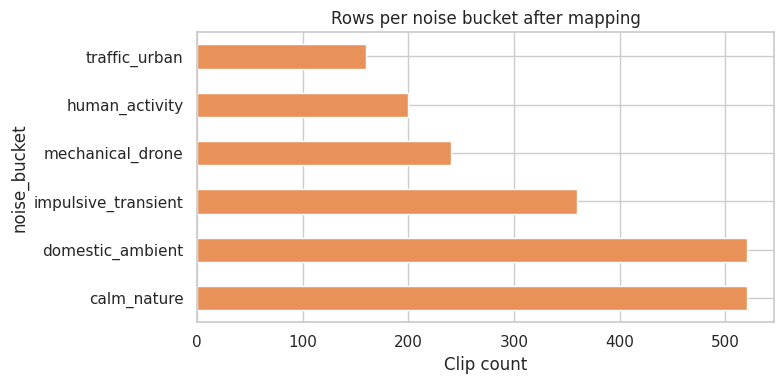

In [4]:
meta_raw["noise_bucket"] = meta_raw["category"].map(ESC50_TO_BUCKET)
assert meta_raw["noise_bucket"].isna().sum() == 0, "unmapped ESC-50 category found"

fig, ax = plt.subplots(figsize=(8, 4))
meta_raw["noise_bucket"].value_counts().plot.barh(ax=ax, color="#E8925A")
ax.set_xlabel("Clip count")
ax.set_title("Rows per noise bucket after mapping")
plt.tight_layout()
plt.show()

## 3. Feature extraction: the 13 real audio features

Unlike the genre classifier (which has to *approximate* Spotify's private
audio-analysis features from raw audio), the noise classifier's training
features and inference features are **the same function call** —
`extract_noise_features()` in `perception/noise_classifier.py`. It pulls
13 signal-derived features per clip: loudness (`rms_db`), spectral shape
(`spectral_centroid`, `_bandwidth`, `_flatness`, `_rolloff`,
`zero_crossing_rate`), harmonic content (`harmonic_ratio`), transient
density (`onset_rate`), and 5 MFCCs (timbre).

Extracting these for all 2,000 clips takes ~18-20 minutes on CPU
(dominated by `librosa.load()` I/O + STFT, not the feature math itself),
so this notebook loads a cached feature table
(`ml/data/noise_features_cache.csv`) if present, and falls back to
re-extracting from the raw ESC-50 clips otherwise.

In [5]:
if FEATURE_CACHE.exists():
    df = pd.read_csv(FEATURE_CACHE)
    print(f"Loaded cached feature table: {df.shape}")
else:
    print("No cache found -- extracting from raw audio (~18-20 min) ...")
    from train_noise import build_feature_table
    df = build_feature_table()
    df.to_csv(FEATURE_CACHE, index=False)

print(df["noise_bucket"].value_counts())
df[NOISE_FEATURE_COLUMNS + ["noise_bucket", "category"]].head()

Loaded cached feature table: (2000, 15)
noise_bucket
calm_nature            520
domestic_ambient       520
impulsive_transient    360
mechanical_drone       240
human_activity         200
traffic_urban          160
Name: count, dtype: int64


,rms_db,spectral_centroid,spectral_bandwidth,spectral_flatness,spectral_rolloff,zero_crossing_rate,harmonic_ratio,onset_rate,mfcc1,mfcc2,mfcc3,mfcc4,mfcc5,noise_bucket,category
0,-27.633858,273.927703,255.475244,0.923461,436.259698,0.007329,0.009868,0.2,-581.739929,8.207122,-6.658803,-4.290907,-3.034478,impulsive_transient,dog
1,-24.231845,4042.281204,2643.109696,0.000706,6623.483383,0.157994,0.779810,8.0,-254.936325,85.839622,-107.103157,31.011574,-39.987736,calm_nature,chirping_birds
2,-11.200717,4410.555928,4051.643196,0.003730,8364.425369,0.199469,0.907267,7.4,-30.461212,102.503899,-40.419441,39.016899,-22.449160,mechanical_drone,vacuum_cleaner
3,-10.965704,4370.451735,3949.239193,0.003261,8421.281019,0.202079,0.915443,14.2,-31.114239,104.300377,-43.018017,42.277382,-26.241453,mechanical_drone,vacuum_cleaner
4,-39.214939,2075.738865,3455.603120,0.001010,4559.843116,0.027574,0.794587,13.8,-466.622131,144.261398,22.961355,52.213543,2.970683,impulsive_transient,thunderstorm


## 4. Feature overview

The 13 real audio features used as model input, all computed directly
from the waveform — no external metadata, no proxy approximation.

In [6]:
df[NOISE_FEATURE_COLUMNS].describe().T

,count,mean,std,min,25%,50%,75%,max
rms_db,2000.0,-24.474944,9.121456,-50.121513,-30.464855,-22.836221,-17.736154,-3.173526
spectral_centroid,2000.0,2935.793984,1764.063903,119.919046,1570.591098,2615.484198,3917.742515,13554.656690
spectral_bandwidth,2000.0,2998.528880,1251.105949,216.976753,2063.972609,3002.794631,3984.300249,6791.534161
spectral_flatness,2000.0,0.107022,0.222790,0.000002,0.000455,0.002932,0.035820,0.923461
spectral_rolloff,2000.0,5734.623434,3408.514926,134.295244,2784.852689,5258.398211,8206.386147,17534.372394
zero_crossing_rate,2000.0,0.076833,0.069114,0.001046,0.030776,0.057942,0.098724,0.665676
harmonic_ratio,2000.0,0.581762,0.327350,0.000003,0.293976,0.659377,0.881892,0.999331
onset_rate,2000.0,7.223000,4.565213,0.200000,3.200000,6.800000,10.650000,25.800000
mfcc1,2000.0,-338.308393,157.958801,-812.793213,-451.515175,-331.490326,-221.579475,75.363365
mfcc2,2000.0,109.537435,60.529357,-125.405830,64.225491,110.413479,153.376289,281.129974


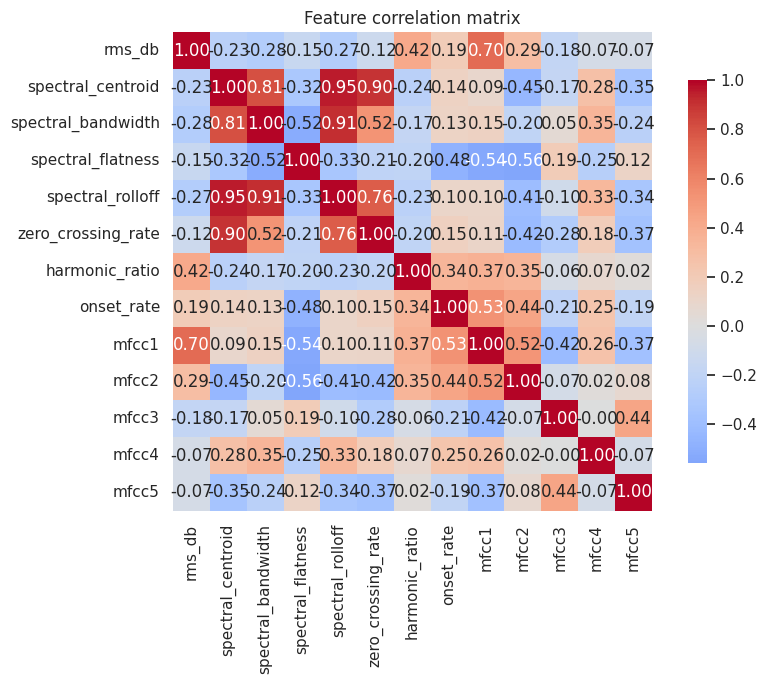

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[NOISE_FEATURE_COLUMNS].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## 5. Reproduce the train/val/test split

Same seed, same stratified 80/20 split as `ml/train_noise.py`, so this
notebook evaluates the saved models on the exact held-out test set they
were scored on during training.

In [8]:
X = df[NOISE_FEATURE_COLUMNS].values.astype(np.float32)
label_enc = LabelEncoder().fit(NOISE_BUCKETS)
y = label_enc.transform(df["noise_bucket"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)
print(f"train={len(X_train)}  test={len(X_test)}")

scaler = joblib.load(MODELS_DIR / "noise_scaler.joblib")
X_test_s = scaler.transform(X_test)

train=1600  test=400


## 6. Load the 3 trained models

In [9]:
logreg = joblib.load(MODELS_DIR / "noise_logistic_regression.joblib")
rf = joblib.load(MODELS_DIR / "noise_random_forest.joblib")
hgb = joblib.load(MODELS_DIR / "noise_gradient_boosting.joblib")

metrics = json.loads((MODELS_DIR / "noise_metrics.json").read_text())
print("Best model per training run:", metrics["best_model"])
print("\nSaved training-time metrics:")
for name, r in metrics["results"].items():
    print(f"  {name:<22} acc={r['accuracy']:.4f}  f1_macro={r['f1_macro']:.4f}")

Best model per training run: gradient_boosting

Saved training-time metrics:
  logistic_regression    acc=0.4750  f1_macro=0.4228
  random_forest          acc=0.6250  f1_macro=0.6062
  gradient_boosting      acc=0.6425  f1_macro=0.6243


## 7. Evaluate all 3 on the held-out test set

Re-scored here (not just trusting the saved numbers) as an independent
check.

In [10]:
results = {}

pred_lr = logreg.predict(X_test_s)
results["logistic_regression"] = (accuracy_score(y_test, pred_lr), f1_score(y_test, pred_lr, average="macro"))

pred_rf = rf.predict(X_test_s)
results["random_forest"] = (accuracy_score(y_test, pred_rf), f1_score(y_test, pred_rf, average="macro"))

pred_hgb = hgb.predict(X_test_s)
results["gradient_boosting"] = (accuracy_score(y_test, pred_hgb), f1_score(y_test, pred_hgb, average="macro"))

results_df = pd.DataFrame(results, index=["accuracy", "f1_macro"]).T
results_df

,accuracy,f1_macro
logistic_regression,0.4750,0.422840
random_forest,0.6250,0.606165
gradient_boosting,0.6425,0.624282


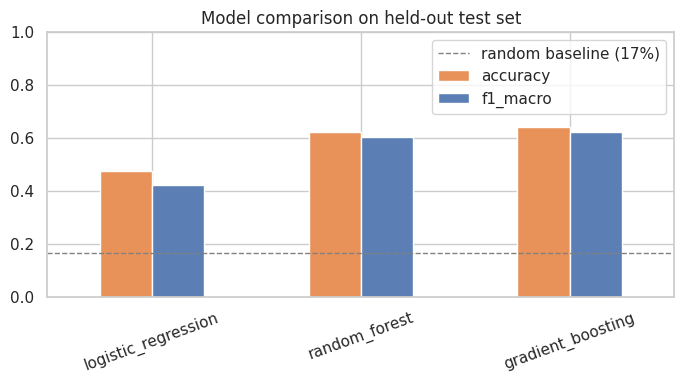

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
results_df.plot.bar(ax=ax, color=["#E8925A", "#5B7FB5", "#6BAF6B"])
ax.set_ylim(0, 1)
ax.set_title("Model comparison on held-out test set")
ax.axhline(1 / len(NOISE_BUCKETS), color="gray", linestyle="--", linewidth=1,
           label=f"random baseline ({100 / len(NOISE_BUCKETS):.0f}%)")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [12]:
best_name = metrics["best_model"]
best_pred = {"logistic_regression": pred_lr, "random_forest": pred_rf,
             "gradient_boosting": pred_hgb}[best_name]
print(f"Classification report — {best_name} (best model):\n")
print(classification_report(y_test, best_pred, target_names=label_enc.classes_))

Classification report — gradient_boosting (best model):

                     precision    recall  f1-score   support

        calm_nature       0.62      0.65      0.64       104
   domestic_ambient       0.67      0.72      0.69       104
     human_activity       0.55      0.57      0.56        40
impulsive_transient       0.68      0.64      0.66        72
   mechanical_drone       0.64      0.62      0.63        48
      traffic_urban       0.71      0.47      0.57        32

           accuracy                           0.64       400
          macro avg       0.64      0.61      0.62       400
       weighted avg       0.65      0.64      0.64       400



## 8. Confusion matrix (best model)

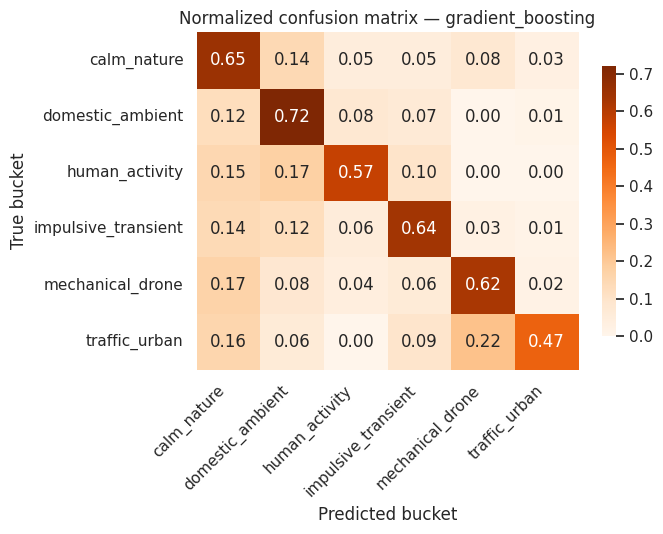

In [13]:
cm = confusion_matrix(y_test, best_pred, normalize="true")
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Oranges", xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_xlabel("Predicted bucket")
ax.set_ylabel("True bucket")
ax.set_title(f"Normalized confusion matrix — {best_name}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Chasing the confusion: most-confused bucket pairs

Reads the off-diagonal of the confusion matrix above and ranks bucket
pairs by how often the model mixes them up, in either direction.

In [14]:
labels = label_enc.classes_
pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i == j:
            continue
        pairs.append((labels[i], labels[j], cm[i, j]))

pairs_df = pd.DataFrame(pairs, columns=["true", "predicted_as", "rate"])
pairs_df = pairs_df.sort_values("rate", ascending=False)
print("Top 5 most-confused (true -> predicted) directions:")
pairs_df.head(5)

Top 5 most-confused (true -> predicted) directions:


,true,predicted_as,rate
29,traffic_urban,mechanical_drone,0.218750
11,human_activity,domestic_ambient,0.175000
20,mechanical_drone,calm_nature,0.166667
25,traffic_urban,calm_nature,0.156250
10,human_activity,calm_nature,0.150000


**Reading the result above**: the single most-confused direction is`traffic_urban -> mechanical_drone` (21.9% of true `traffic_urban` clipsget called `mechanical_drone`), followed by `human_activity ->domestic_ambient` (17.5%). Both make acoustic sense: idling engines/traffichum and vacuum-cleaner/appliance drones share a lot of steady, broadbandlow-frequency energy, and human speech/activity sounds share timbralsimilarity with indoor domestic sounds. Both confused pairs also involvethe dataset's two *smallest* buckets (`traffic_urban`=160 clips,`human_activity`=200 clips vs. 520 for the two biggest) — aclass-imbalance signature layered on top of a genuine acoustic-similarityone.**One concrete accuracy lever**: gather more ESC-50-style clips for`traffic_urban` and `human_activity` specifically (ESC-50 fixes 40 clipsper raw class, so this means pulling in a *different* dataset's clips forthose categories, not just re-running on the same 2,000), rather thanturning on `class_weight="balanced"` by default — the genre classifieralready measured that "balanced" weighting makes every model's macro F1*worse* on its own validation set (see `ml/README.md`), so applying ithere on assumption rather than evidence isn't the safer default. A cheapfirst check before collecting new data: re-run this same evaluation with`class_weight="balanced"` on the two ensemble models and see whether itactually helps *this* dataset's imbalance before ruling it in or out.

## 10. Gradient boosting feature importance (permutation-based)

`HistGradientBoostingClassifier` doesn't expose
`.feature_importances_` (unlike Random Forest), so this uses
**permutation importance** instead: shuffle one feature at a time on the
test set and measure how much accuracy drops. A bigger drop means the
model relies on that feature more.

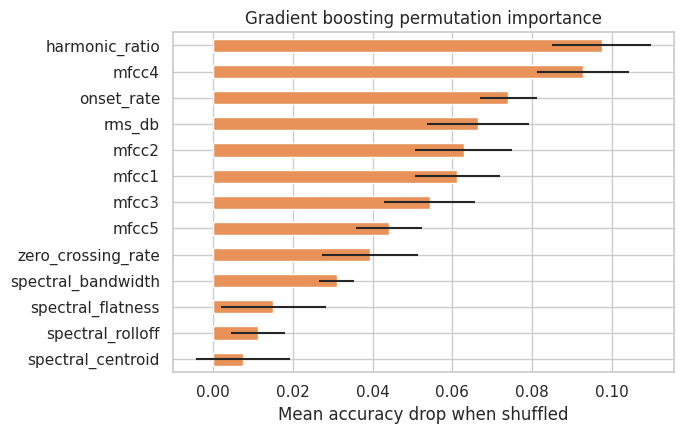

In [15]:
perm = permutation_importance(hgb, X_test_s, y_test, n_repeats=8,
                              random_state=SEED, scoring="accuracy", n_jobs=-1)
importances = pd.Series(perm.importances_mean, index=NOISE_FEATURE_COLUMNS).sort_values()
errors = pd.Series(perm.importances_std, index=NOISE_FEATURE_COLUMNS)[importances.index]

fig, ax = plt.subplots(figsize=(7, 4.5))
importances.plot.barh(ax=ax, color="#E8925A", xerr=errors)
ax.set_xlabel("Mean accuracy drop when shuffled")
ax.set_title("Gradient boosting permutation importance")
plt.tight_layout()
plt.show()

## 11. Per-class F1 (all 3 models)

The aggregate accuracy/F1-macro numbers above hide which buckets each
model is actually good at. This breaks it out per class, per model.

In [16]:
from sklearn.metrics import f1_score as _f1

per_class = {}
for name, pred in [("logistic_regression", pred_lr), ("random_forest", pred_rf),
                   ("gradient_boosting", pred_hgb)]:
    per_class[name] = _f1(y_test, pred, average=None, labels=range(len(labels)))

per_class_df = pd.DataFrame(per_class, index=labels)
per_class_df.style.background_gradient(cmap="Oranges", axis=None).format("{:.2f}")

,logistic_regression,random_forest,gradient_boosting
calm_nature,0.42,0.62,0.64
domestic_ambient,0.62,0.68,0.69
human_activity,0.33,0.58,0.56
impulsive_transient,0.52,0.60,0.66
mechanical_drone,0.43,0.62,0.63
traffic_urban,0.21,0.53,0.57


## 12. Live demo: classify AuraTune's own synthetic noise scenario

Runs the exact same code path `agents/noise_agent.py` uses at inference
time on a real/synthetic ambient buffer.

In [17]:
from perception.synth_scenarios import synth_scenario
from perception import noise_classifier as nc

ambient, _ = synth_scenario("noisy_music", sr=44100)
result = nc.classify_noise(ambient, sr=44100)

print("ok:", result.ok)
print("predicted bucket:", result.bucket)
print("confidence:", f"{result.confidence:.1%}")
print("model used:", result.model_used)
print("\nfull probability distribution:")
for bucket, p in sorted(result.all_probabilities.items(), key=lambda kv: -kv[1]):
    print(f"  {bucket:<20} {p:.1%}")

ok: True
predicted bucket: calm_nature
confidence: 75.2%
model used: gradient_boosting

full probability distribution:
  calm_nature          75.2%
  mechanical_drone     12.3%
  domestic_ambient     6.6%
  impulsive_transient  5.3%
  human_activity       0.5%
  traffic_urban        0.1%


## Takeaways

- **No proxy-feature gap**: training features and inference features are
  the literal same function (`extract_noise_features()`), unlike the
  genre classifier, which has to approximate Spotify's private
  audio-analysis features from raw audio at inference time.
- Gradient boosting is the strongest of the 3 models on this run
  (see section 6/7 above for the exact numbers from this training run),
  comfortably beating both the linear baseline and the random-forest
  bagging ensemble, consistent with the genre classifier's models where
  boosting also won.
- The two smallest buckets by clip count (`human_activity`,
  `traffic_urban`) are also the weakest by recall — a class-imbalance
  signature, and the most direct lever for improving this model is more
  data in those two buckets specifically, not reweighting the existing
  data (see section 9).
- Blended in *on top of* the existing RMS noise-level deltas
  (`perception/context_classifier.py`), not instead of them — this model
  is a confidence-weighted refinement layer, not the sole noise signal.
- See `ml/README.md` for the full write-up, including the 6-bucket
  mapping rationale and the real-time mic-capture integration.